In [38]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [39]:
df = pd.read_csv("/content/3) Sentiment dataset.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [40]:
df  = df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], axis = 1)
df.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [41]:
df = df[['Text', 'Sentiment']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Text       732 non-null    object
 1   Sentiment  732 non-null    object
dtypes: object(2)
memory usage: 11.6+ KB


In [42]:
df = df.dropna()

In [43]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['Text'] = df['Text'].apply(clean_text)
print("\nUnique sentiments:", df['Sentiment'].unique())


Unique sentiments: [' Positive  ' ' Negative  ' ' Neutral   ' ' Anger        '
 ' Fear         ' ' Sadness      ' ' Disgust      ' ' Happiness    '
 ' Joy          ' ' Love         ' ' Amusement    ' ' Enjoyment    '
 ' Admiration   ' ' Affection    ' ' Awe          ' ' Disappointed '
 ' Surprise     ' ' Acceptance   ' ' Adoration    ' ' Anticipation '
 ' Bitter       ' ' Calmness     ' ' Confusion    ' ' Excitement   '
 ' Kind         ' ' Pride        ' ' Shame        ' ' Confusion '
 ' Excitement ' ' Shame ' ' Elation       ' ' Euphoria      '
 ' Contentment   ' ' Serenity      ' ' Gratitude     ' ' Hope          '
 ' Empowerment   ' ' Compassion    ' ' Tenderness    ' ' Arousal       '
 ' Enthusiasm    ' ' Fulfillment  ' ' Reverence     ' ' Compassion'
 ' Fulfillment   ' ' Reverence ' ' Elation   ' ' Despair         '
 ' Grief           ' ' Loneliness      ' ' Jealousy        '
 ' Resentment      ' ' Frustration     ' ' Boredom         '
 ' Anxiety         ' ' Intimidation    ' ' H

In [44]:
# Normalize labels
df['Sentiment'] = df['Sentiment'].str.strip().str.lower()

# Define categories
positive_words = [
    'positive','happy','happiness','joy','love','admiration','amusement',
    'enjoyment','excitement','gratitude','hope','pride','confidence',
    'optimism','enthusiasm','affection','delight','euphoria','contentment',
    'serenity','inspiration','kindness','friendship','success','celebration'
]

negative_words = [
    'negative','sad','sadness','anger','fear','disgust','grief','despair',
    'loneliness','jealousy','resentment','frustration','boredom','anxiety',
    'regret','hate','bad','shame','guilt','suffering','heartbreak'
]

# Map function
def map_sentiment(label):
    if label in positive_words:
        return 1
    elif label in negative_words:
        return 0
    else:
        return 2  # neutral / unknown

df['Sentiment'] = df['Sentiment'].apply(map_sentiment)

In [45]:
print(df['Sentiment']), print("\nLabel Distribution:")
print(df['Sentiment'].value_counts())


0      1
1      0
2      1
3      1
4      2
      ..
727    1
728    1
729    1
730    1
731    1
Name: Sentiment, Length: 732, dtype: int64

Label Distribution:
Sentiment
2    387
1    249
0     96
Name: count, dtype: int64


In [46]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=3000
)

X = vectorizer.fit_transform(df['Text'])
y = df['Sentiment']

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [48]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [49]:
y_pred = knn.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.7346938775510204

Confusion Matrix:
[[12  3  6]
 [ 0 36 11]
 [ 5 14 60]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.57      0.63        21
           1       0.68      0.77      0.72        47
           2       0.78      0.76      0.77        79

    accuracy                           0.73       147
   macro avg       0.72      0.70      0.71       147
weighted avg       0.74      0.73      0.73       147



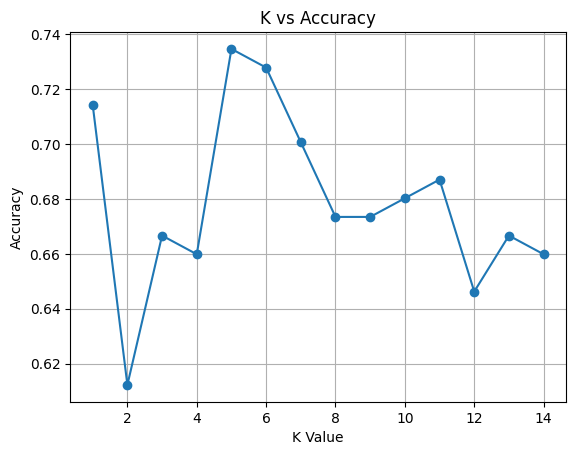

In [50]:
#Tune K-value
k_values = range(1, 15)
scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

plt.plot(k_values, scores, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.grid()
plt.show()

In [51]:
best_k = k_values[np.argmax(scores)]
best_score = max(scores)

print(f"\nBest K: {best_k}")
print(f"Best Accuracy: {best_score:.4f}")


Best K: 5
Best Accuracy: 0.7347
